# Flower manifold: train VP-SDE score net

1D manifold in R^2: a starlike "flower" curve `r(theta) = a + b*cos(k*theta)`, `(x, y) = r(theta) * (cos theta, sin theta)`,
`theta` in `[0, 2*pi)`. Unlike the `toy_manifold` sine-wave line, this curve is *compact* (closed, bounded).
Keeping `a > b` keeps `r(theta) > 0` everywhere, so the curve stays simple (non-self-intersecting, no cusps at
the origin) no matter how many lobes `k` gives it — that's what makes it look like a flower instead of a rose
curve's pinched petals. Jacobian is still closed-form: `dr/dtheta = -k*b*sin(k*theta)`,
speed `= sqrt(r(theta)**2 + (dr/dtheta)**2)`.

Trains a noise-prediction score net on a frozen set of atoms sampled along the curve, exactly as in
`toy_manifold/01_train_score.ipynb`. Saves a checkpoint that a corresponding `02_fr_guidance.ipynb` can load.

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

ITERS_BY_REGIME = {"normal": 50000, "overtrained": 500000}   # overtrained = many more passes over the same
                                                            # fixed atoms, to induce memorization

config = {
    "regime": os.environ.get("REGIME", "overtrained"),   # picks both the checkpoint name
                          # (checkpoints/score_{regime}_N{N_data}.pt) and iters (ITERS_BY_REGIME above)
                          # -- changing N_data alone does NOT change the regime; iters is what actually
                          # controls overtraining/memorization
    "N_data": int(os.environ.get("N_DATA", 50)),
    "a": 1.0, "b": 0.35, "k": 5,   # flower radius: r(theta) = a + b*cos(k*theta), a > b keeps r > 0 everywhere
    "d": 2,
    "beta_min": 0.1, "beta_max": 20.0, "T": 1.0,
    "hidden": 128, "depth": 3, "batch": 256, "lr": 2e-4,
    "n_steps": 200,
    "seed": 0,
    "device": os.environ.get("DEVICE", "cpu"),
}
config["iters"] = ITERS_BY_REGIME[config["regime"]]
torch.manual_seed(config["seed"])
d, device = config["d"], config["device"]
print(f"d={d}, device={device}, regime={config['regime']}, N_data={config['N_data']}, iters={config['iters']}")

# This notebook's own figure outputs (manifold/training/sampling/Laguerre plots) go here, one folder
# per (N_data, regime) combo, same convention as toy_manifold/02_fr_guidance.ipynb. The trained
# checkpoint itself still saves flat to checkpoints/score_{regime}_N{N_data}.pt (see last cell).
OUT_DIR = f"checkpoints/N{config['N_data']}-{config['regime']}"
os.makedirs(OUT_DIR, exist_ok=True)
print(f"figures -> {OUT_DIR}/")

d=2, device=cpu, regime=overtrained, N_data=50, iters=500000
figures -> checkpoints/N50-overtrained/


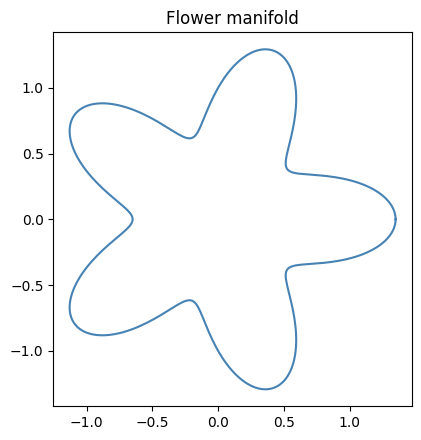

In [2]:
def manifold_from_u(u):
    r = config["a"] + config["b"] * torch.cos(config["k"] * u)
    return torch.stack([r * torch.cos(u), r * torch.sin(u)], dim=-1)

theta_curve = torch.linspace(0, 2 * torch.pi, 400)
curve = manifold_from_u(theta_curve)

plt.figure(figsize=(4.5, 4.5))
plt.plot(curve[:, 0], curve[:, 1], color="steelblue", lw=1.5)
plt.gca().set_aspect("equal")
plt.title("Flower manifold")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/flower_manifold.png", dpi=120); plt.show()

X_target: torch.Size([50, 2])


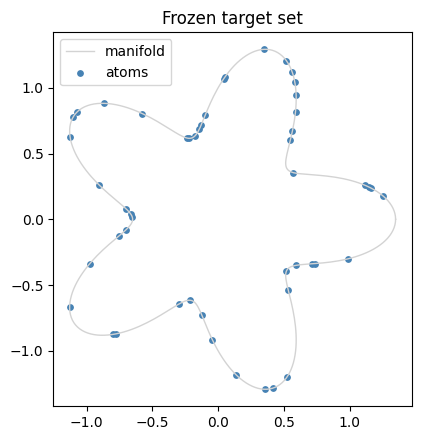

In [3]:
u_target = torch.rand(config["N_data"]) * 2 * torch.pi
X_target = manifold_from_u(u_target).to(device)
print(f"X_target: {X_target.shape}")

plt.figure(figsize=(4.5, 4.5))
plt.plot(curve[:, 0], curve[:, 1], color="lightgray", lw=1, label="manifold")
plt.scatter(X_target[:, 0].cpu(), X_target[:, 1].cpu(), s=15, color="steelblue", label="atoms")
plt.gca().set_aspect("equal")
plt.legend(); plt.title("Frozen target set"); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/frozen_target_set.png", dpi=120); plt.show()

## Laguerre / entropic-OT cell boundaries

Semi-discrete optimal transport from a uniform source over a bounding box to the discrete target atoms
above (equal mass `1/N_data` each), swept across entropic temperature `eps`. `eps -> 0` gives the hard
Laguerre diagram — plain Voronoi here, since every atom carries equal mass; larger `eps` blurs the
boundaries into soft assignment probabilities.

Colors: Delaunay triangulation of the atoms is the exact dual graph of their Voronoi/Laguerre diagram, so
its edges are precisely which cells touch. Greedy (Welsh-Powell) graph coloring then assigns the fewest
hues such that touching cells always differ — colors repeat freely across the flower (there are far more
atoms than colors) but never between two neighboring cells, the same principle a country map uses.

In [4]:
import numpy as np
from scipy.special import logsumexp
from scipy.spatial import Delaunay

ys = X_target.cpu().numpy().astype(np.float32)
N_data = ys.shape[0]

def cost_matrix(x, y):
    d = x[:, None, :] - y[None, :, :]
    return np.sum(d**2, axis=-1)

def log_posterior(phi, C, eps):
    scores = (phi[None, :] - C) / eps
    return scores - logsumexp(scores, axis=1, keepdims=True)

def soft_c_transform(phi, C, eps):
    return -eps * logsumexp((phi[None, :] - C) / eps, axis=1)

def normalize(field):
    lo, hi = np.nanmin(field), np.nanmax(field)
    return (field - lo) / (hi - lo)

In [5]:
RES = 350
nu = np.ones(N_data, dtype=np.float32) / N_data

pad = 0.4
lg_xlo, lg_xhi = ys[:, 0].min() - pad, ys[:, 0].max() + pad
lg_ylo, lg_yhi = ys[:, 1].min() - pad, ys[:, 1].max() + pad
lin_x = np.linspace(lg_xlo, lg_xhi, RES, dtype=np.float32)
lin_y = np.linspace(lg_ylo, lg_yhi, RES, dtype=np.float32)
lg_xx, lg_yy = np.meshgrid(lin_x, lin_y)
lg_grid = np.stack([lg_xx.ravel(), lg_yy.ravel()], axis=1).astype(np.float32)
C_grid  = cost_matrix(lg_grid, ys)
print(f"grid: {RES}x{RES}, C_grid: {C_grid.shape}")

psi_hard      = C_grid.min(axis=1)
winner_hard   = C_grid.argmin(axis=1).reshape(lg_xx.shape).astype(np.int64)
psi_hard_norm = normalize(psi_hard).reshape(lg_xx.shape)

grid: 350x350, C_grid: (122500, 50)


In [6]:
tri = Delaunay(ys)
adjacency = [set() for _ in range(N_data)]
for simplex in tri.simplices:
    for i in simplex:
        for j in simplex:
            if i != j:
                adjacency[i].add(j)

order = sorted(range(N_data), key=lambda i: -len(adjacency[i]))
color_idx = np.full(N_data, -1)
for node in order:
    used = {color_idx[nb] for nb in adjacency[node] if color_idx[nb] != -1}
    c = 0
    while c in used:
        c += 1
    color_idx[node] = c
n_colors = color_idx.max() + 1
print(f"{n_colors} colors needed for {N_data} atoms (max cell degree {max(len(a) for a in adjacency)})")

# dataviz skill's validated categorical palette (light mode)
PALETTE_HEX = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
               "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

def hex_to_rgb(h):
    h = h.lstrip("#")
    return np.array([int(h[i:i + 2], 16) for i in (0, 2, 4)]) / 255.0

palette = np.stack([hex_to_rgb(h) for h in PALETTE_HEX])
if n_colors > len(palette):
    import colorsys
    extra = [colorsys.hsv_to_rgb(i / n_colors, 0.75, 0.85) for i in range(len(palette), n_colors)]
    palette = np.concatenate([palette, np.array(extra)])
palette = np.clip(palette, 0.06, 1.0)   # keep every channel > 0 so the log-blend below stays finite

site_colors = palette[color_idx]

5 colors needed for 50 atoms (max cell degree 9)


In [7]:
# phi = 0 everywhere as a proxy for the true entropic dual potential: atoms carry equal mass and are
# roughly evenly spaced along the curve, so the exact dual solution is already close to constant, and
# skipping the stochastic dual ascent (solving semi-discrete OT properly) is a fast, good approximation.
EPSILONS   = [0.003, 0.008, 0.02, 0.05]
phi_zero   = np.zeros(N_data, dtype=np.float32)
ot_results = []

for eps in EPSILONS:
    psi_norm = normalize(soft_c_transform(phi_zero, C_grid, eps))
    q_2d     = np.exp(log_posterior(phi_zero, C_grid, eps)).reshape(RES, RES, N_data)
    ot_results.append(dict(eps=eps, psi_norm=psi_norm.reshape(lg_xx.shape), q_2d=q_2d))

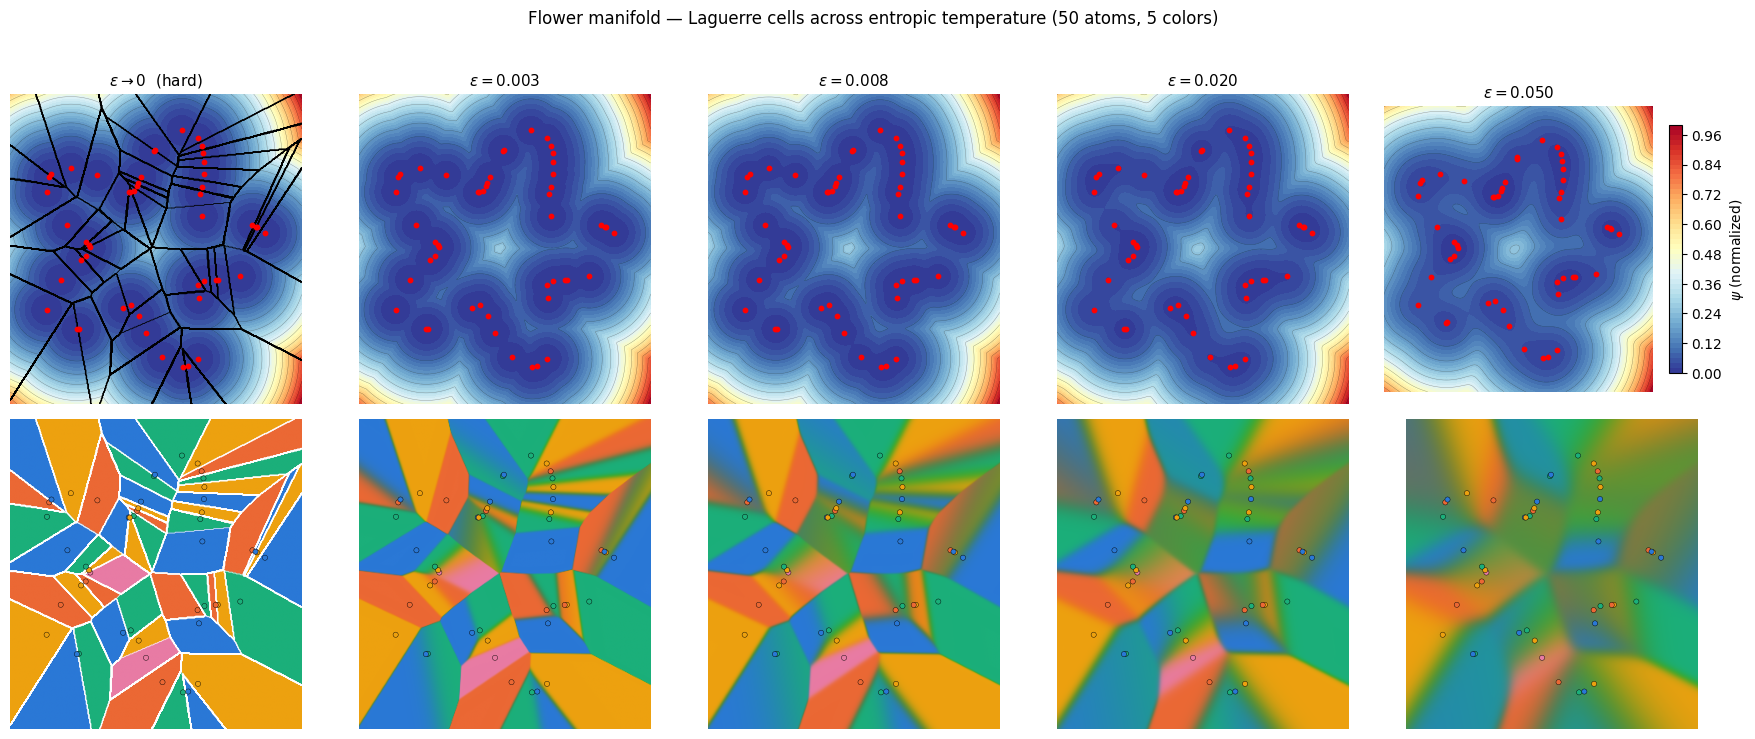

In [8]:
log_colors = np.log(site_colors)

def blend(q_2d):
    return np.exp(np.einsum('ijk,kl->ijl', q_2d, log_colors)).clip(0, 1)

lg_extent  = [lg_xlo, lg_xhi, lg_ylo, lg_yhi]
hard_blend = site_colors[winner_hard]

panels = (
    [(psi_hard_norm, hard_blend, True, r'$\varepsilon \to 0$  (hard)')] +
    [(r['psi_norm'], blend(r['q_2d']), False, rf'$\varepsilon={r["eps"]:.3f}$') for r in ot_results]
)

fig, axes = plt.subplots(2, len(panels), figsize=(len(panels) * 3.6, 7.2))
for col, (psi, rgb, show_boundary, title) in enumerate(panels):
    ax = axes[0, col]
    im = ax.contourf(lg_xx, lg_yy, psi, levels=50, cmap='RdYlBu_r', vmin=0, vmax=1)
    ax.contour(lg_xx, lg_yy, psi, levels=15, colors='k', linewidths=0.3, alpha=0.4)
    if show_boundary:
        ax.contour(lg_xx, lg_yy, winner_hard, levels=np.arange(0.5, N_data - 0.5), colors='k', linewidths=0.6)
    ax.scatter(ys[:, 0], ys[:, 1], s=10, color='red', zorder=5)
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal'); ax.axis('off')

    ax = axes[1, col]
    ax.imshow(rgb, origin='lower', extent=lg_extent, aspect='equal')
    if show_boundary:
        ax.contour(lg_xx, lg_yy, winner_hard, levels=np.arange(0.5, N_data - 0.5), colors='white', linewidths=0.6, alpha=0.8)
    ax.scatter(ys[:, 0], ys[:, 1], c=site_colors, s=14, edgecolors='k', linewidths=0.3, zorder=5)
    ax.axis('off')

axes[0, 0].set_ylabel('cost field'); axes[1, 0].set_ylabel('color blend')
fig.colorbar(im, ax=axes[0, -1], shrink=0.8, label=r'$\psi$ (normalized)')
fig.suptitle(f'Flower manifold — Laguerre cells across entropic temperature ({N_data} atoms, {n_colors} colors)', y=1.02)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/laguerre_boundaries.png", dpi=120, bbox_inches="tight"); plt.show()

In [9]:
def beta(t):
    return config["beta_min"] + t * (config["beta_max"] - config["beta_min"])

def alpha_bar(t):
    return torch.exp(-(config["beta_min"] * t + 0.5 * (config["beta_max"] - config["beta_min"]) * t ** 2))

def q_sample(x0, t):
    eps = torch.randn_like(x0)
    a = alpha_bar(t)[:, None]
    return a.sqrt() * x0 + (1 - a).sqrt() * eps, eps

In [10]:
class ScoreNet(nn.Module):
    def __init__(self, d, hidden, depth):
        super().__init__()
        self.input_proj = nn.Linear(d + 1, hidden)
        self.layers = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(depth * 2)])
        self.output_proj = nn.Linear(hidden, d)

    def forward(self, x, t):
        h = F.silu(self.input_proj(torch.cat([x, t[:, None]], dim=-1)))
        for i in range(0, len(self.layers), 2):
            r = F.silu(self.layers[i](h))
            r = self.layers[i + 1](r)
            h = h + r
        return self.output_proj(h)

net = ScoreNet(d, config["hidden"], config["depth"]).to(device)
print(f"Parameters: {sum(p.numel() for p in net.parameters()):,}")

def loss_fn(net, x0):
    t = torch.rand(x0.shape[0], device=x0.device).clamp(min=1e-3) * config["T"]
    xt, eps = q_sample(x0, t)
    return ((net(xt, t) - eps) ** 2).mean()

Parameters: 99,842


iter      0  loss=1.0860
iter  25000  loss=0.1882
iter  50000  loss=0.1874
iter  75000  loss=0.1393
iter 100000  loss=0.1891
iter 125000  loss=0.1924
iter 150000  loss=0.1949
iter 175000  loss=0.2184
iter 200000  loss=0.2193
iter 225000  loss=0.1393
iter 250000  loss=0.1346
iter 275000  loss=0.2008
iter 300000  loss=0.1789
iter 325000  loss=0.1842
iter 350000  loss=0.2242
iter 375000  loss=0.1325
iter 400000  loss=0.1894
iter 425000  loss=0.1819
iter 450000  loss=0.1876
iter 475000  loss=0.1386
Training done.


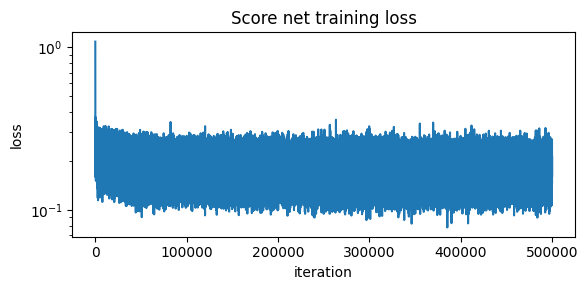

In [11]:
opt = torch.optim.Adam(net.parameters(), lr=config["lr"])
losses = []
print_every = max(1, config["iters"] // 20)
for i in range(config["iters"]):
    idx = torch.randint(0, config["N_data"], (config["batch"],))
    loss = loss_fn(net, X_target[idx])
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    if i % print_every == 0:
        print(f"iter {i:6d}  loss={loss.item():.4f}")
net.eval()
print("Training done.")

plt.figure(figsize=(6, 3))
plt.semilogy(losses)
plt.xlabel("iteration"); plt.ylabel("loss"); plt.title("Score net training loss")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/training_loss.png", dpi=120); plt.show()

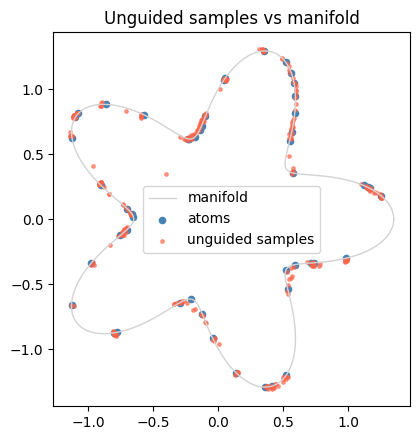

In [12]:
def sample(B, n_steps=None):
    n_steps = n_steps or config["n_steps"]
    x = torch.randn(B, d, device=device)
    dt = config["T"] / n_steps
    for k in reversed(range(n_steps)):
        t = torch.full((B,), (k + 1) * dt, device=device)
        eps_hat = net(x, t)
        score = -eps_hat / (1 - alpha_bar(t))[:, None].sqrt()
        drift = -0.5 * beta(t)[:, None] * x - beta(t)[:, None] * score
        noise = beta(t)[:, None].sqrt() * torch.randn_like(x) if k > 0 else 0
        x = x - drift * dt + noise * dt ** 0.5
    return x.detach()

with torch.no_grad():
    X_gen = sample(300)

plt.figure(figsize=(4.5, 4.5))
plt.plot(curve[:, 0], curve[:, 1], color="lightgray", lw=1, label="manifold")
plt.scatter(X_target[:, 0].cpu(), X_target[:, 1].cpu(), s=20, color="steelblue", label="atoms")
plt.scatter(X_gen[:, 0].cpu(), X_gen[:, 1].cpu(), s=6, color="tomato", alpha=0.6, label="unguided samples")
plt.gca().set_aspect("equal")
plt.legend(); plt.title("Unguided samples vs manifold"); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/unguided_samples.png", dpi=120); plt.show()

In [13]:
os.makedirs("checkpoints", exist_ok=True)
ckpt_path = f"checkpoints/score_{config['regime']}_N{config['N_data']}.pt"
torch.save({
    "net_state": net.state_dict(),
    "X_target": X_target.cpu(),
    "u_target": u_target.cpu(),
    "config": config,
}, ckpt_path)
print(f"Saved {ckpt_path}")

Saved checkpoints/score_overtrained_N50.pt
